# *Clustering Track - Beijing Multi-Site Air Quality Analysis*

This section focuses on the application of unsupervised machine learning techniques to identify meaningful patterns and groups within air quality observations.

The dataset used for this track is the **Beijing Multi-Site Air Quality Data** obtained from the UCI Machine Learning Repository.

Unlike supervised learning, clustering does not use a target variable during model training. The objective is to discover natural groupings in the observations based on their air quality and meteorological characteristics.

The clustering track implements the two algorithms specified in the project guidelines:

1. K-Means Clustering
2. Agglomerative Hierarchical Clustering

The clustering results will be evaluated using:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

Cluster structures will also be visualized using PCA and t-SNE.

## *1. Problem Statement*

Air quality varies across different locations and time periods due to differences in pollutant concentrations and meteorological conditions.

The objective of this clustering analysis is to group air quality observations into distinct clusters based on their underlying pollutant and environmental characteristics.

The analysis considers measurements such as PM2.5, PM10, SO2, NO2, CO, O3 and meteorological variables including temperature, pressure, dew point, rainfall, wind speed and wind direction.

Since there is no predefined target class for the clustering task, the models will identify groups directly from the feature space.

The resulting clusters will then be examined to understand the characteristics of different air quality patterns.

In [1]:
# Import required libraries

import os
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


## *2. Dataset Loading*

### *2.1 Dataset Source*

The dataset used for this clustering track is the **Beijing Multi-Site Air Quality Data** from the UCI Machine Learning Repository.

The dataset contains air quality measurements collected from multiple monitoring sites in Beijing along with meteorological observations.

The original dataset is stored as a compressed archive inside the project's `data/clustering/` directory.

The raw dataset will be inspected before any preprocessing is performed.

In [3]:
# Locate the clustering dataset

from pathlib import Path

# Possible locations depending on the notebook working directory
possible_paths = [
    Path("data/clustering/beijing_multi_site_air_quality_data.zip"),
    Path("../data/clustering/beijing_multi_site_air_quality_data.zip"),
    Path("../../data/clustering/beijing_multi_site_air_quality_data.zip")
]

zip_path = None

for path in possible_paths:
    if path.exists():
        zip_path = path.resolve()
        break

if zip_path is None:
    raise FileNotFoundError(
        "Dataset ZIP file was not found. "
        "Make sure it is saved inside data/clustering/"
    )

print("Dataset found successfully.")
print("Dataset path:")
print(zip_path)

Dataset found successfully.
Dataset path:
C:\Users\appal\Downloads\Machine-Learning-Case-Study\data\clustering\beijing_multi_site_air_quality_data.zip


### *2.2 Inspecting the Dataset Archive*

Before extracting and loading the data, the contents of the compressed archive are inspected.

This step helps identify the available monitoring-station files and prevents assumptions about the internal file structure of the downloaded dataset.

In [4]:
# Inspect the contents of the ZIP archive

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    file_list = zip_ref.namelist()

print("Number of files in archive:", len(file_list))
print("\nFiles contained in the archive:\n")

for file_name in file_list:
    print(file_name)

Number of files in archive: 4

Files contained in the archive:

PRSA2017_Data_20130301-20170228.zip
2A2478DC-8517-4490-9FA7-36F9A7A542BE.JPG
data.csv
test.csv


## *2.3 Dataset Extraction*

The downloaded archive contains multiple files, including a compressed dataset archive and CSV files.

The contents will be extracted into a temporary clustering data directory. The extracted files will then be inspected to determine their structure before selecting the data used for clustering.

No preprocessing or clustering operation is performed at this stage.

In [5]:
# Extract the outer ZIP archive

extract_dir = zip_path.parent / "extracted"

# Create extraction directory if it does not already exist
extract_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Outer archive extracted successfully.")
print("\nExtracted files:")

for item in sorted(extract_dir.rglob("*")):
    if item.is_file():
        print(item.relative_to(extract_dir))

Outer archive extracted successfully.

Extracted files:
2A2478DC-8517-4490-9FA7-36F9A7A542BE.JPG
data.csv
PRSA2017_Data_20130301-20170228.zip
test.csv


### *2.4 Inspecting the Raw Air Quality Dataset*

The archive contains a second compressed file named `PRSA2017_Data_20130301-20170228.zip`.

This archive is inspected separately to identify the original air-quality monitoring station files before loading the observations.

In [6]:
# Locate the nested Beijing air-quality dataset archive

nested_zip_path = extract_dir / "PRSA2017_Data_20130301-20170228.zip"

if not nested_zip_path.exists():
    raise FileNotFoundError(
        "The nested PRSA dataset ZIP was not found."
    )

# Inspect the nested ZIP contents
with zipfile.ZipFile(nested_zip_path, "r") as zip_ref:
    nested_file_list = zip_ref.namelist()

print("Number of files in nested ZIP:", len(nested_file_list))
print("\nFiles in nested ZIP:\n")

for file_name in nested_file_list:
    print(file_name)

Number of files in nested ZIP: 13

Files in nested ZIP:

PRSA_Data_20130301-20170228/
PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Nongzhanguan_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Shunyi_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Tiantan_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Wanliu_20130301-20170228.csv
PRSA_Data_20130301-20170228/PRSA_Data_Wanshouxigong_20130301-20170228.csv


## *3. Dataset Extraction and Loading*

The nested dataset contains air-quality observations from multiple monitoring stations in Beijing.

There are 12 station-level CSV files:

- Aotizhongxin
- Changping
- Dingling
- Dongsi
- Guanyuan
- Gucheng
- Huairou
- Nongzhanguan
- Shunyi
- Tiantan
- Wanliu
- Wanshouxigong

Each station contains observations collected over the same study period.

The station-level files will be extracted and later combined into a single dataset. A station identifier will be retained so that differences between monitoring locations can be examined during cluster profiling.

In [7]:
# Extract the nested Beijing air-quality dataset

raw_data_dir = extract_dir / "raw_air_quality"

raw_data_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(nested_zip_path, "r") as zip_ref:
    zip_ref.extractall(raw_data_dir)

print("Nested air-quality dataset extracted successfully.")

Nested air-quality dataset extracted successfully.


In [8]:
# Find all station CSV files

station_files = sorted(raw_data_dir.rglob("*.csv"))

print("Number of station CSV files:", len(station_files))
print("\nStation files:\n")

for file in station_files:
    print(file.relative_to(raw_data_dir))

Number of station CSV files: 12

Station files:

PRSA_Data_20130301-20170228\PRSA_Data_Aotizhongxin_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Nongzhanguan_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Shunyi_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Tiantan_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Wanliu_20130301-20170228.csv
PRSA_Data_20130301-20170228\PRSA_Data_Wanshouxigong_20130301-20170228.csv


### *3.1 Inspecting a Station Dataset*

Before combining the station-level datasets, the structure of one station file is examined.

This includes the column names, data types, sample observations and dataset dimensions. The same structure will then be verified across the remaining station files.

In [9]:
# Load and inspect the first station dataset

sample_df = pd.read_csv(station_files[0])

print("Station file:")
print(station_files[0].name)

print("\nShape:")
print(sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

print("\nData types:")
print(sample_df.dtypes)

print("\nFirst five rows:")
display(sample_df.head())

Station file:
PRSA_Data_Aotizhongxin_20130301-20170228.csv

Shape:
(35064, 18)

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Data types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

First five rows:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [10]:
# Check the structure of all station datasets

print("Checking station dataset structures...\n")

reference_columns = sample_df.columns.tolist()

for file in station_files:
    df_check = pd.read_csv(file)

    same_columns = df_check.columns.tolist() == reference_columns

    print(
        f"{file.name}: "
        f"rows={len(df_check)}, "
        f"columns={len(df_check.columns)}, "
        f"same_structure={same_columns}"
    )

Checking station dataset structures...

PRSA_Data_Aotizhongxin_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Changping_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Dingling_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Dongsi_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Guanyuan_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Gucheng_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Huairou_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Nongzhanguan_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Shunyi_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Tiantan_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Wanliu_20130301-20170228.csv: rows=35064, columns=18, same_structure=True
PRSA_Data_Wans

### *3.2 Combining Monitoring Stations*

The individual station datasets are combined into one DataFrame so that the clustering algorithms can analyze observations from all monitoring locations.

A `station` column is added before combining the files. This identifier is retained for later interpretation and cluster profiling but will not be used as a numerical clustering feature.

In [11]:
# Load and combine all station datasets

station_dataframes = []

for file in station_files:
    
    df_station = pd.read_csv(file)
    
    # Extract station name from filename
    station_name = file.stem.replace(
        "PRSA_Data_", ""
    ).replace(
        "_20130301-20170228", ""
    )
    
    # Add station identifier
    df_station["station"] = station_name
    
    station_dataframes.append(df_station)

# Combine all stations
air_quality_df = pd.concat(
    station_dataframes,
    ignore_index=True
)

print("Combined dataset created successfully.")
print("Shape:", air_quality_df.shape)

display(air_quality_df.head())

Combined dataset created successfully.
Shape: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [12]:
# Basic audit of the combined dataset

print("Dataset shape:")
print(air_quality_df.shape)

print("\nColumn names:")
print(air_quality_df.columns.tolist())

print("\nData types:")
display(air_quality_df.dtypes)

print("\nMissing values:")
display(air_quality_df.isnull().sum())

print("\nNumber of observations by station:")
display(air_quality_df["station"].value_counts())

print("\nDescriptive statistics:")
display(air_quality_df.describe(include="all"))

Dataset shape:
(420768, 18)

Column names:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

Data types:


No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object


Missing values:


No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64


Number of observations by station:


station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64


Descriptive statistics:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,418946,420450.000000,420768
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,12
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Aotizhongxin
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43335,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,NaN,1.729711,NaN
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,NaN,1.246386,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,NaN,2.200000,NaN


## *4. Exploratory Data Analysis*

Exploratory Data Analysis (EDA) is performed to understand the distribution, variability and relationships among the air-quality and meteorological variables.

The analysis includes:

1. Missing-value analysis
2. Distribution of pollutant concentrations
3. Distribution of meteorological variables
4. Correlation analysis
5. Station-wise air-quality analysis
6. Examination of unusual or extreme values

The findings from EDA will guide the preprocessing and feature-selection steps used before clustering.

### *4.1 Missing-Value Analysis*

Missing observations are present in several air-quality and meteorological variables.

The proportion of missing values is calculated for each feature to determine the extent of missing data before selecting an appropriate treatment strategy.

In [13]:
# Calculate missing-value counts and percentages

missing_summary = pd.DataFrame({
    "Missing Count": air_quality_df.isnull().sum(),
    "Missing Percentage": (
        air_quality_df.isnull().mean() * 100
    )
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
CO,20701,4.919813
O3,13277,3.155421
NO2,12116,2.879497
SO2,9021,2.143937
PM2.5,8739,2.076916
PM10,6449,1.532674
wd,1822,0.433018
DEWP,403,0.095777
TEMP,398,0.094589
PRES,393,0.093401


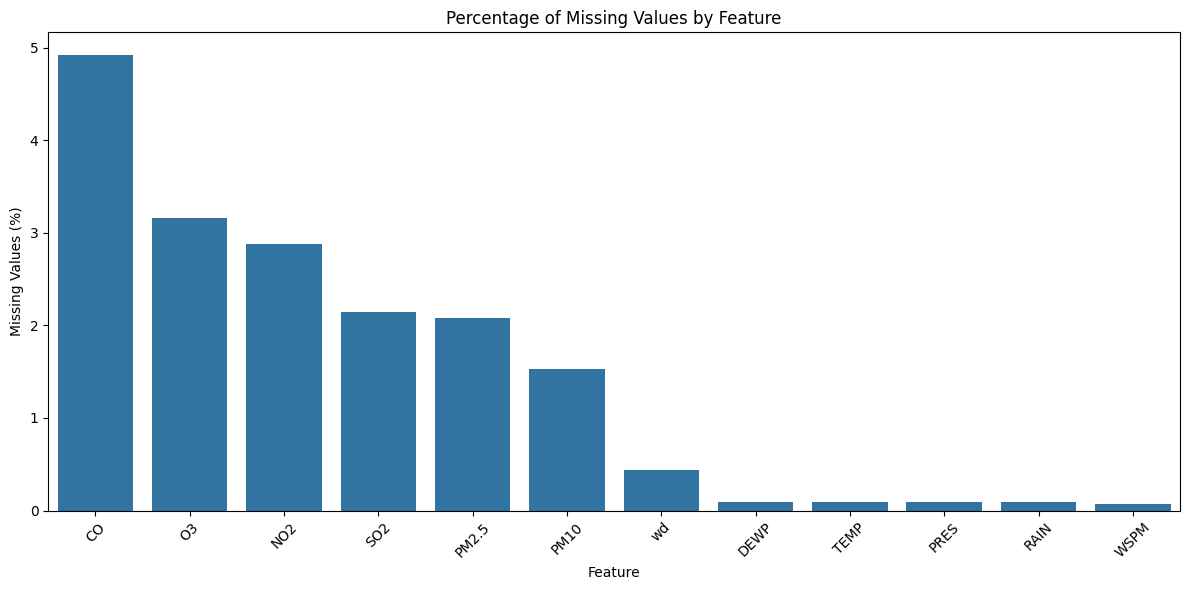

In [14]:
# Visualize missing values

missing_plot = missing_summary[
    missing_summary["Missing Count"] > 0
]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot["Missing Percentage"]
)

plt.xticks(rotation=45)
plt.ylabel("Missing Values (%)")
plt.xlabel("Feature")
plt.title("Percentage of Missing Values by Feature")
plt.tight_layout()
plt.show()

### *4.2 Distribution of Air Pollutants*

The distributions of the major air pollutants are examined to understand their typical ranges and identify highly skewed variables or extreme observations.

The pollutant variables considered are:

- PM2.5
- PM10
- SO2
- NO2
- CO
- O3

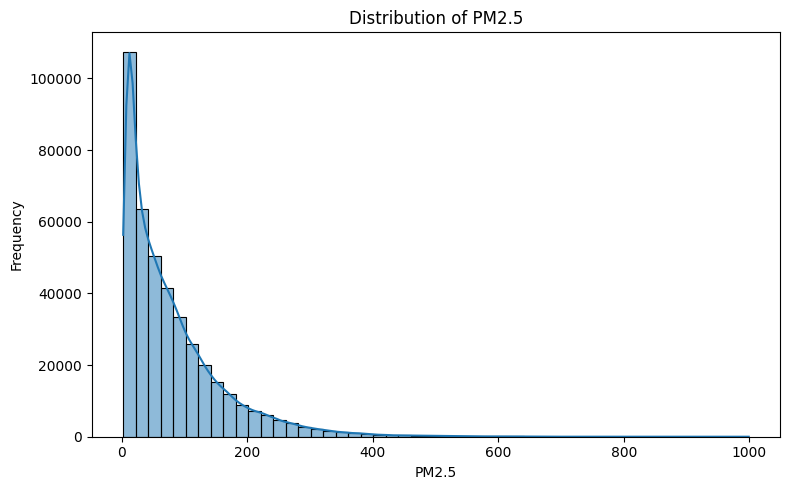

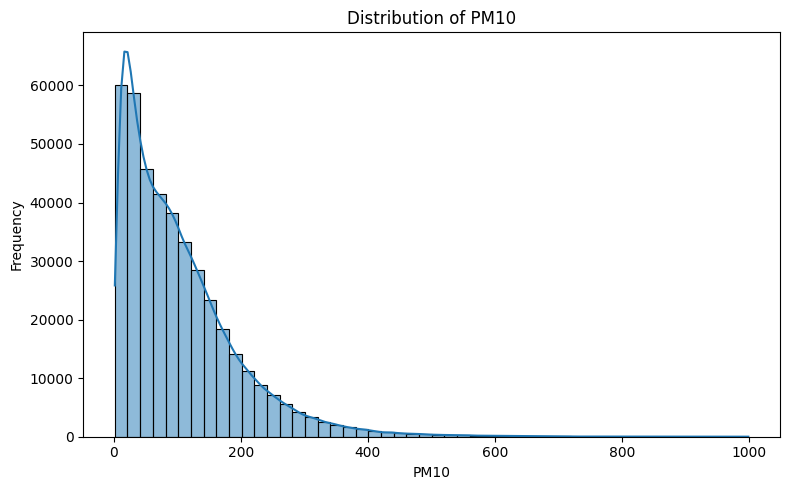

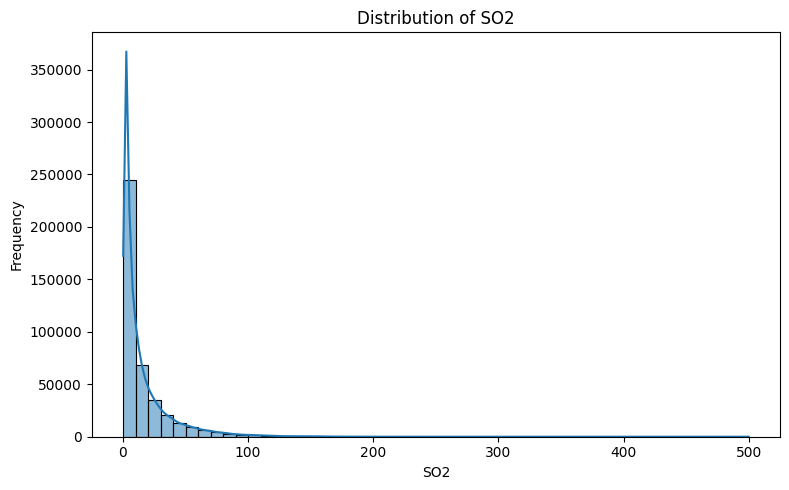

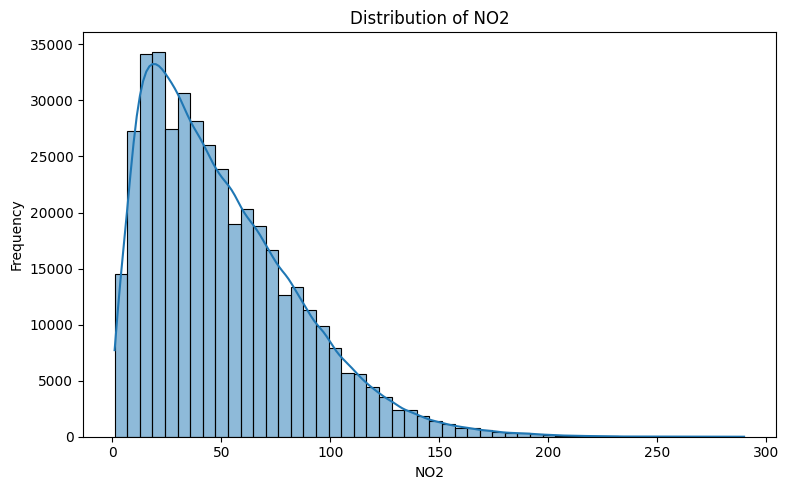

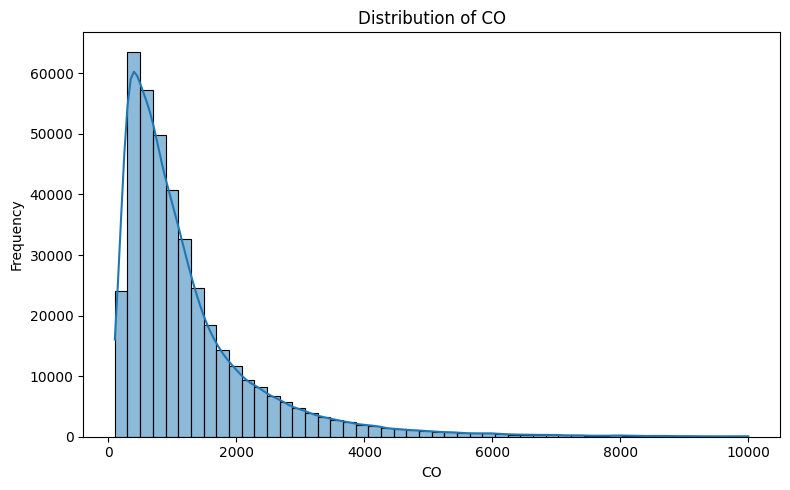

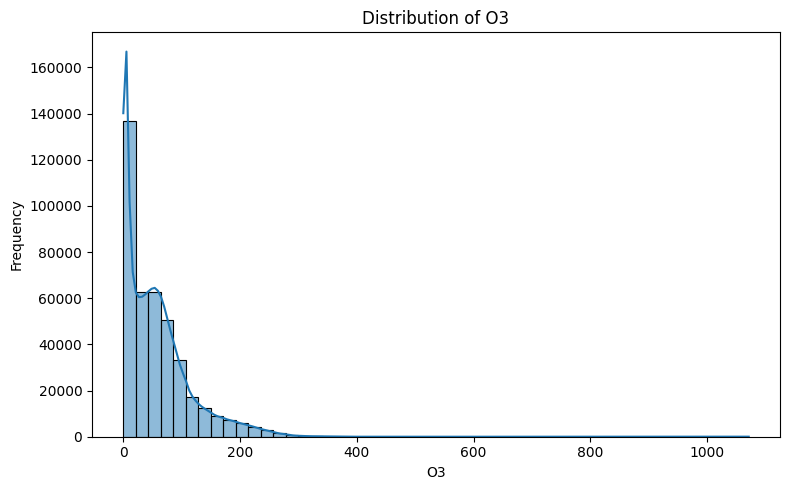

In [15]:
# Plot distributions of pollutant variables

pollutant_features = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]

for feature in pollutant_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        air_quality_df[feature].dropna(),
        bins=50,
        kde=True
    )
    
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {feature}")
    plt.tight_layout()
    plt.show()

### *4.3 Outlier and Extreme-Value Inspection*

Boxplots are used to examine the spread of pollutant concentrations and identify observations that lie far from the central distribution.

Extreme observations are not automatically removed at this stage because unusually high pollution measurements may represent genuine air-quality events. Their treatment will be considered after further inspection.

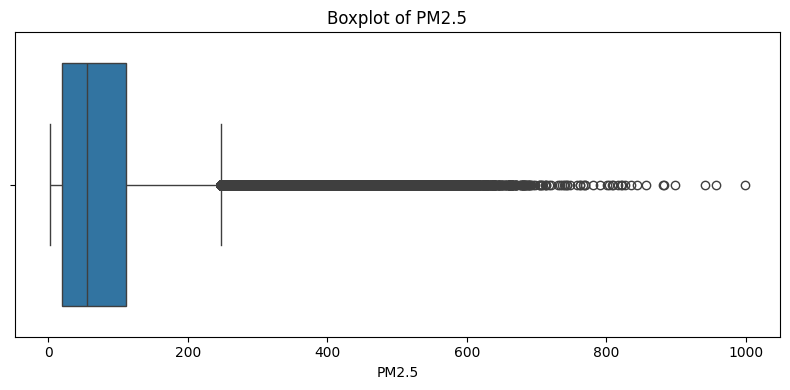

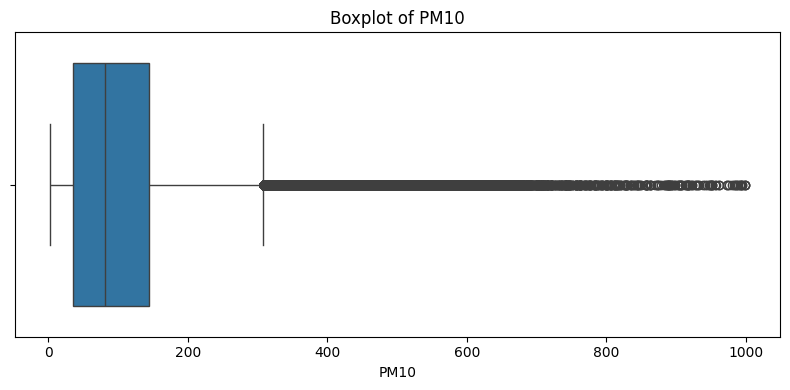

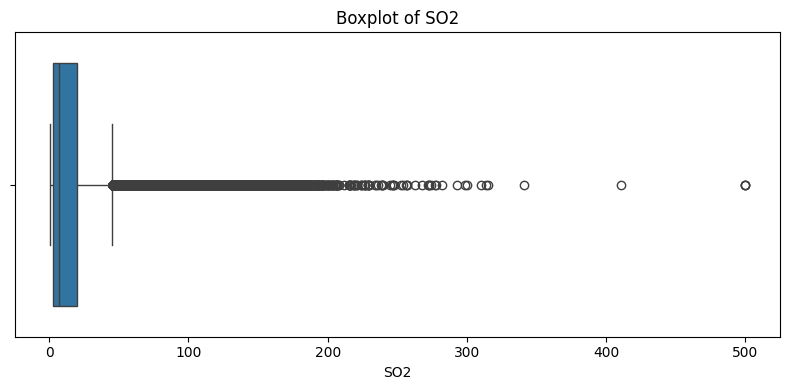

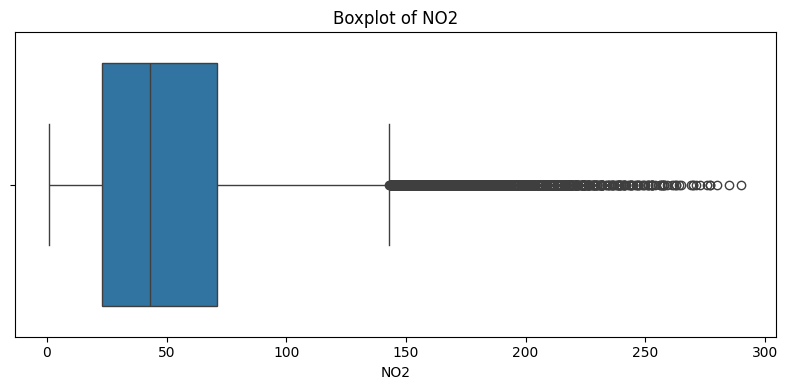

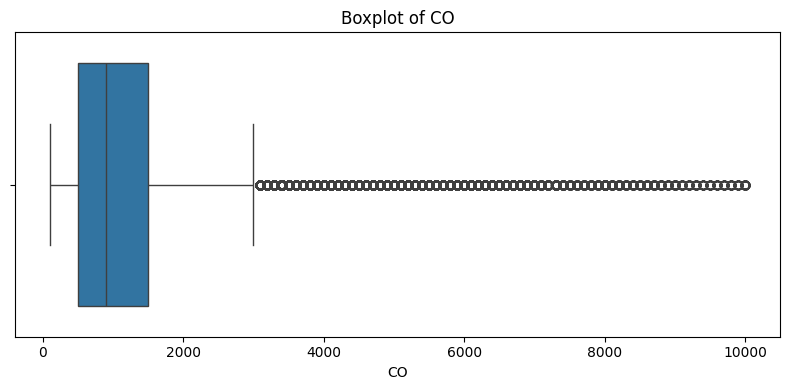

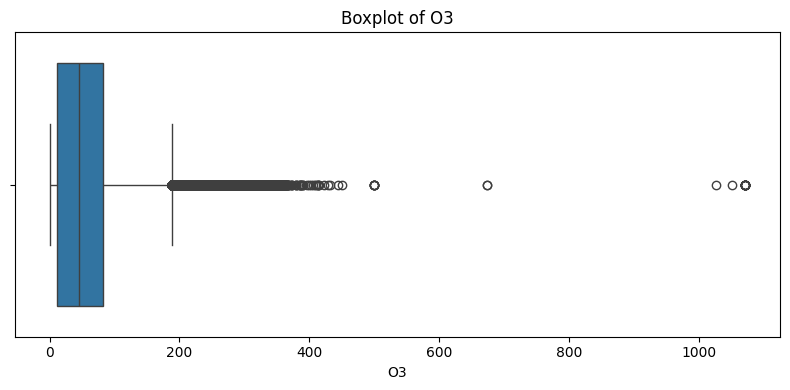

In [16]:
# Boxplots for pollutant variables

for feature in pollutant_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(
        x=air_quality_df[feature]
    )
    
    plt.xlabel(feature)
    plt.title(f"Boxplot of {feature}")
    plt.tight_layout()
    plt.show()

### *4.4 Examination of Extreme Values*

The descriptive statistics show unusually high maximum values for some pollutant variables.

These values are examined separately to determine their frequency and whether they require treatment during preprocessing.

No values are removed solely because they are extreme.

In [17]:
# Count selected extreme values

extreme_checks = {
    "PM2.5 = 999": (air_quality_df["PM2.5"] == 999).sum(),
    "PM10 = 999": (air_quality_df["PM10"] == 999).sum(),
    "CO = 10000": (air_quality_df["CO"] == 10000).sum(),
    "SO2 = 500": (air_quality_df["SO2"] == 500).sum(),
    "O3 = 1071": (air_quality_df["O3"] == 1071).sum()
}

extreme_summary = pd.DataFrame(
    list(extreme_checks.items()),
    columns=["Condition", "Count"]
)

display(extreme_summary)

,Condition,Count
0,PM2.5 = 999,1
1,PM10 = 999,3
2,CO = 10000,56
3,SO2 = 500,3
4,O3 = 1071,14


### *4.5 Correlation Analysis*

Correlation analysis is used to examine relationships between pollutant concentrations and meteorological variables.

Strong relationships between variables are relevant to clustering because highly related features can contribute overlapping information to the feature space.

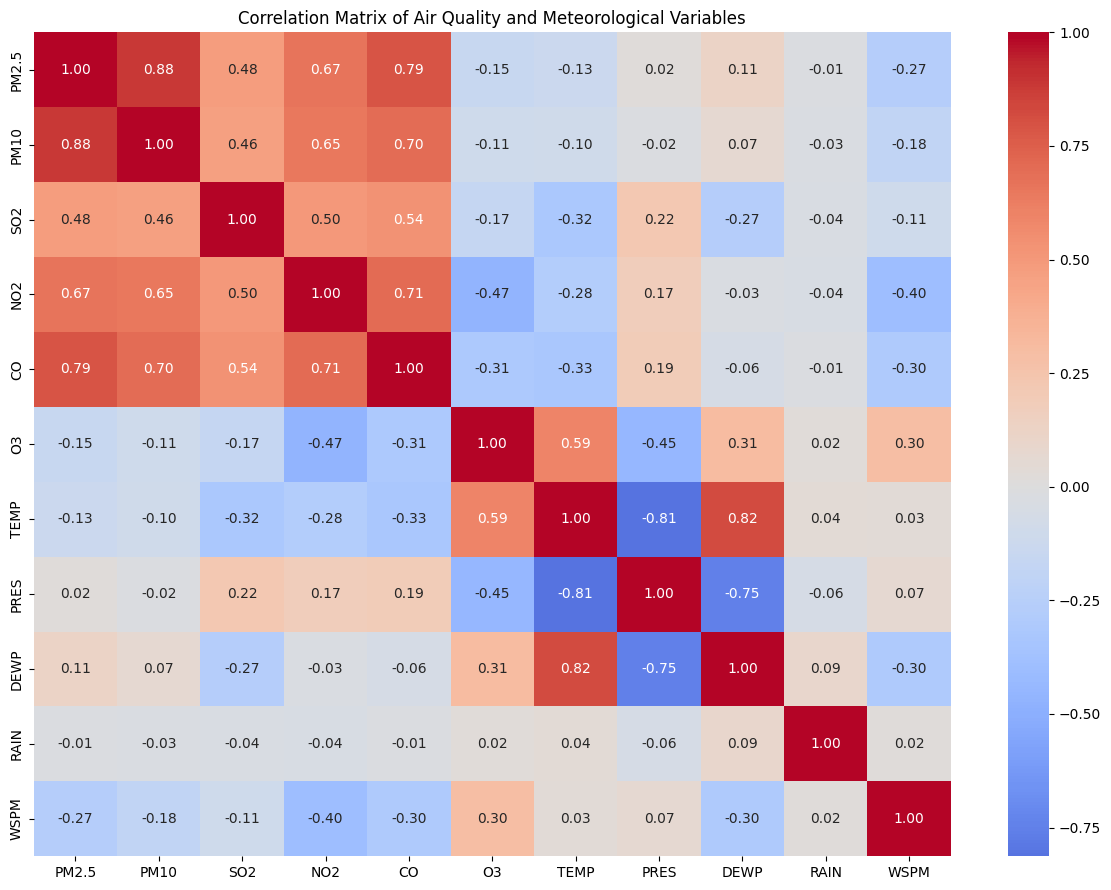

In [18]:
# Select numerical environmental variables for correlation analysis

correlation_features = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

correlation_matrix = air_quality_df[
    correlation_features
].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Air Quality and Meteorological Variables")
plt.tight_layout()
plt.show()

### *4.6 Station-Wise Air Quality Analysis*

The dataset contains observations from 12 monitoring stations.

Station-wise pollutant averages are examined to determine whether air-quality characteristics differ between monitoring locations.

The station identifier will be retained for interpretation and cluster profiling but will not be directly used as a numerical clustering feature.

In [19]:
# Calculate average pollutant concentrations by station

station_pollution = (
    air_quality_df
    .groupby("station")[pollutant_features]
    .mean()
    .sort_values("PM2.5", ascending=False)
)

display(station_pollution)

,PM2.5,PM10,SO2,NO2,CO,O3
station,,,,,,
Dongsi,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637
Wanshouxigong,85.024136,112.223459,17.148603,55.529560,1370.395031,56.229904
Nongzhanguan,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682
Gucheng,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879
Wanliu,83.374716,110.464618,18.376481,65.258789,1319.353513,48.873614
Guanyuan,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044
Aotizhongxin,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358
Tiantan,82.164911,106.363672,14.367615,53.162646,1298.303318,55.984297
Shunyi,79.491602,98.737026,13.572039,43.908865,1187.063979,55.201321


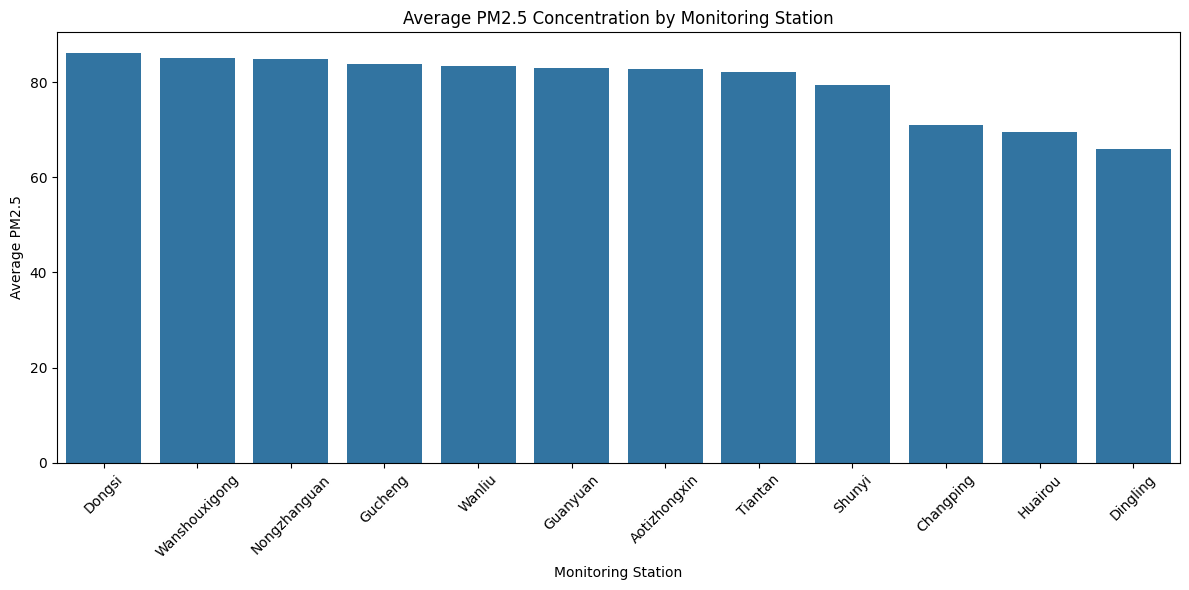

In [20]:
# Visualize average PM2.5 concentration by station

plt.figure(figsize=(12, 6))

sns.barplot(
    data=station_pollution.reset_index(),
    x="station",
    y="PM2.5"
)

plt.xticks(rotation=45)
plt.xlabel("Monitoring Station")
plt.ylabel("Average PM2.5")
plt.title("Average PM2.5 Concentration by Monitoring Station")
plt.tight_layout()
plt.show()

### *4.7 Detailed Examination of Extreme Observations*

The extreme observations identified during EDA are examined in their original context.

Their frequency is low relative to the complete dataset. Therefore, they are not removed automatically. Their surrounding pollutant and meteorological measurements are inspected before deciding how they should be handled during preprocessing.

In [21]:
# Inspect observations containing the identified extreme values

extreme_rows = air_quality_df[
    (air_quality_df["PM2.5"] == 999) |
    (air_quality_df["PM10"] == 999) |
    (air_quality_df["CO"] == 10000) |
    (air_quality_df["SO2"] == 500) |
    (air_quality_df["O3"] == 1071)
]

print("Number of rows containing at least one identified extreme value:")
print(len(extreme_rows))

display(
    extreme_rows[
        [
            "year", "month", "day", "hour",
            "PM2.5", "PM10", "SO2", "NO2",
            "CO", "O3", "TEMP", "PRES",
            "DEWP", "RAIN", "wd", "WSPM",
            "station"
        ]
    ].sort_values(
        ["CO", "O3", "PM2.5"],
        ascending=False
    ).head(30)
)

Number of rows containing at least one identified extreme value:
77


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
370475,2015,6,5,11,72.0,102.0,6.0,85.0,10000.0,86.0,26.6,992.9,14.4,0.0,SW,1.4,Wanliu
160075,2015,6,4,19,68.0,84.0,7.0,46.0,10000.0,86.0,20.6,996.9,14.9,0.0,SSW,2.4,Guanyuan
265266,2015,6,4,18,65.0,65.0,14.0,44.0,10000.0,86.0,20.9,996.5,14.3,0.0,WSW,1.2,Nongzhanguan
160077,2015,6,4,21,73.0,75.0,6.0,43.0,10000.0,80.0,19.6,996.8,14.6,0.0,W,1.1,Guanyuan
370461,2015,6,4,21,71.0,71.0,7.0,49.0,10000.0,80.0,19.4,995.5,16.1,0.0,WSW,1.1,Wanliu
265267,2015,6,4,19,68.0,74.0,11.0,56.0,10000.0,79.0,20.6,996.9,14.9,0.0,SSW,2.4,Nongzhanguan
265269,2015,6,4,21,71.0,71.0,9.0,48.0,10000.0,77.0,19.6,996.8,14.6,0.0,W,1.1,Nongzhanguan
125007,2015,6,4,15,40.0,40.0,4.0,32.0,10000.0,74.0,17.8,998.8,15.8,1.9,S,1.9,Dongsi
160091,2015,6,5,11,71.0,82.0,5.0,79.0,10000.0,73.0,25.6,994.7,12.1,0.0,E,2.4,Guanyuan
265270,2015,6,4,22,71.0,71.0,8.0,48.0,10000.0,70.0,19.6,996.8,14.6,0.0,WSW,1.7,Nongzhanguan


In [22]:
# Examine high percentiles of pollutant distributions

percentiles = [0.90, 0.95, 0.99, 0.995, 0.999, 1.00]

pollutant_quantiles = (
    air_quality_df[pollutant_features]
    .quantile(percentiles)
)

display(pollutant_quantiles)

,PM2.5,PM10,SO2,NO2,CO,O3
0.900,185.0,222.0,41.24064,99.0,2600.0,133.0
0.950,242.0,279.0,60.00000,117.0,3500.0,177.0
0.990,370.0,422.0,104.00000,157.0,6000.0,245.0
0.995,432.0,494.0,123.00000,173.0,7000.0,265.0
0.999,564.0,666.0,166.00000,204.0,9000.0,312.0
1.000,999.0,999.0,500.00000,290.0,10000.0,1071.0


## *5. Data Preprocessing*

The preprocessing stage prepares the air-quality observations for unsupervised clustering.

The following steps are performed:

1. Remove non-informative identifiers.
2. Handle missing observations.
3. Encode wind direction using a cyclic representation.
4. Construct relevant temporal features.
5. Select environmental features for clustering.
6. Reduce the influence of highly skewed pollutant distributions.
7. Standardize the final feature matrix.

The original `air_quality_df` is preserved so that the raw observations remain available for interpretation and cluster profiling.

### *5.1 Removing Non-Informative Identifiers*

The `No` column is a row identifier rather than an environmental measurement. It is therefore excluded from the clustering feature space.

The `station` column is retained separately for later cluster interpretation but is not directly supplied to the clustering algorithms.

In [23]:
# Create a working copy for preprocessing

cluster_df = air_quality_df.copy()

# Remove row identifier from the clustering dataset
cluster_df = cluster_df.drop(columns=["No"])

print("Working dataset shape:", cluster_df.shape)
print("\nRemaining columns:")
print(cluster_df.columns.tolist())

Working dataset shape: (420768, 17)

Remaining columns:
['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


### *5.2 Temporal Feature Engineering*

The original dataset contains separate year, month, day and hour columns.

Time-of-day and seasonal patterns are cyclic. For example, hour 23 and hour 0 represent adjacent points in the daily cycle.

To preserve this cyclic structure, sine and cosine transformations are used for the hour and month variables.

In [24]:
# Create cyclic temporal features

cluster_df["hour_sin"] = np.sin(
    2 * np.pi * cluster_df["hour"] / 24
)

cluster_df["hour_cos"] = np.cos(
    2 * np.pi * cluster_df["hour"] / 24
)

cluster_df["month_sin"] = np.sin(
    2 * np.pi * (cluster_df["month"] - 1) / 12
)

cluster_df["month_cos"] = np.cos(
    2 * np.pi * (cluster_df["month"] - 1) / 12
)

print("Cyclic temporal features created successfully.")

display(
    cluster_df[
        [
            "hour",
            "hour_sin",
            "hour_cos",
            "month",
            "month_sin",
            "month_cos"
        ]
    ].head()
)

Cyclic temporal features created successfully.


,hour,hour_sin,hour_cos,month,month_sin,month_cos
0,0,0.000000,1.000000,3,0.866025,0.5
1,1,0.258819,0.965926,3,0.866025,0.5
2,2,0.500000,0.866025,3,0.866025,0.5
3,3,0.707107,0.707107,3,0.866025,0.5
4,4,0.866025,0.500000,3,0.866025,0.5


### *5.3 Wind Direction Encoding*

Wind direction is a categorical variable with 16 compass directions.

A direct numerical encoding would introduce an artificial ordering between directions. Instead, each direction is mapped to its corresponding compass angle and represented using sine and cosine components.

This preserves the circular nature of wind direction.

In [25]:
# Map wind directions to compass angles

wind_direction_angles = {
    "N": 0,
    "NNE": 22.5,
    "NE": 45,
    "ENE": 67.5,
    "E": 90,
    "ESE": 112.5,
    "SE": 135,
    "SSE": 157.5,
    "S": 180,
    "SSW": 202.5,
    "SW": 225,
    "WSW": 247.5,
    "W": 270,
    "WNW": 292.5,
    "NW": 315,
    "NNW": 337.5
}

cluster_df["wd_angle"] = cluster_df["wd"].map(
    wind_direction_angles
)

# Convert degrees to radians
wd_radians = np.deg2rad(cluster_df["wd_angle"])

# Cyclic representation
cluster_df["wd_sin"] = np.sin(wd_radians)
cluster_df["wd_cos"] = np.cos(wd_radians)

print("Wind direction encoding completed.")

display(
    cluster_df[
        ["wd", "wd_angle", "wd_sin", "wd_cos"]
    ].head(10)
)

Wind direction encoding completed.


,wd,wd_angle,wd_sin,wd_cos
0,NNW,337.5,-0.382683,0.923880
1,N,0.0,0.000000,1.000000
2,NNW,337.5,-0.382683,0.923880
3,NW,315.0,-0.707107,0.707107
4,N,0.0,0.000000,1.000000
5,N,0.0,0.000000,1.000000
6,NNE,22.5,0.382683,0.923880
7,NNW,337.5,-0.382683,0.923880
8,NNW,337.5,-0.382683,0.923880
9,N,0.0,0.000000,1.000000


### *5.4 Missing-Value Treatment*

Missing values are present in pollutant and meteorological measurements.

Because clustering requires a complete numerical feature matrix, missing values must be handled before model fitting.

The missing values will be imputed using the median of each numerical feature. Median imputation is less sensitive to the highly skewed pollutant distributions observed during EDA.

In [26]:
# Check missing values in the variables intended for clustering

preliminary_features = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "wd_sin",
    "wd_cos"
]

missing_before_imputation = cluster_df[
    preliminary_features
].isnull().sum()

display(
    missing_before_imputation[
        missing_before_imputation > 0
    ].sort_values(ascending=False)
)

CO        20701
O3        13277
NO2       12116
SO2        9021
PM2.5      8739
PM10       6449
wd_cos     1822
wd_sin     1822
DEWP        403
TEMP        398
PRES        393
RAIN        390
WSPM        318
dtype: int64

In [27]:
# Median imputation for numerical clustering features

cluster_df[preliminary_features] = (
    cluster_df[preliminary_features]
    .fillna(
        cluster_df[preliminary_features].median()
    )
)

print("Missing-value imputation completed.")

remaining_missing = (
    cluster_df[preliminary_features]
    .isnull()
    .sum()
    .sum()
)

print("Remaining missing values:", remaining_missing)

Missing-value imputation completed.
Remaining missing values: 0


### *5.5 Transformation of Skewed Pollutant Features*

The EDA showed that several pollutant variables have strongly right-skewed distributions and contain high-concentration observations.

Since K-Means and Agglomerative Clustering are distance-based methods, highly skewed variables can disproportionately influence the resulting clusters.

A logarithmic transformation using `log1p(x)` is therefore applied to the pollutant variables. The transformation reduces skewness while preserving all observations.

The original pollutant values are retained in the raw dataset for later cluster interpretation.

In [28]:
# Apply log1p transformation to pollutant variables

log_pollutant_features = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]

for feature in log_pollutant_features:
    cluster_df[f"{feature}_log"] = np.log1p(
        cluster_df[feature]
    )

print("Logarithmic transformation completed.")

display(
    cluster_df[
        log_pollutant_features +
        [f"{feature}_log" for feature in log_pollutant_features]
    ].head()
)

Logarithmic transformation completed.


,PM2.5,PM10,SO2,NO2,CO,O3,PM2.5_log,PM10_log,SO2_log,NO2_log,CO_log,O3_log
0,4.0,4.0,4.0,7.0,300.0,77.0,1.609438,1.609438,1.609438,2.079442,5.70711,4.356709
1,8.0,8.0,4.0,7.0,300.0,77.0,2.197225,2.197225,1.609438,2.079442,5.70711,4.356709
2,7.0,7.0,5.0,10.0,300.0,73.0,2.079442,2.079442,1.791759,2.397895,5.70711,4.304065
3,6.0,6.0,11.0,11.0,300.0,72.0,1.945910,1.945910,2.484907,2.484907,5.70711,4.290459
4,3.0,3.0,12.0,12.0,300.0,72.0,1.386294,1.386294,2.564949,2.564949,5.70711,4.290459


### *5.6 Final Clustering Feature Selection*

The final clustering feature set combines air-quality measurements, meteorological conditions and cyclic temporal and wind-direction representations.

The station identifier is excluded from model fitting because it is categorical and represents the monitoring location rather than a continuous environmental measurement.

The original pollutant variables are replaced by their logarithmically transformed versions in the clustering feature matrix.

In [29]:
# Define the final clustering features

clustering_features = [
    "PM2.5_log",
    "PM10_log",
    "SO2_log",
    "NO2_log",
    "CO_log",
    "O3_log",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "wd_sin",
    "wd_cos"
]

X_cluster = cluster_df[clustering_features].copy()

print("Number of clustering features:", X_cluster.shape[1])
print("Number of observations:", X_cluster.shape[0])

print("\nClustering features:")
print(X_cluster.columns.tolist())

display(X_cluster.head())

Number of clustering features: 17
Number of observations: 420768

Clustering features:
['PM2.5_log', 'PM10_log', 'SO2_log', 'NO2_log', 'CO_log', 'O3_log', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'wd_sin', 'wd_cos']


,PM2.5_log,PM10_log,SO2_log,NO2_log,CO_log,O3_log,TEMP,PRES,DEWP,RAIN,WSPM,hour_sin,hour_cos,month_sin,month_cos,wd_sin,wd_cos
0,1.609438,1.609438,1.609438,2.079442,5.70711,4.356709,-0.7,1023.0,-18.8,0.0,4.4,0.000000,1.000000,0.866025,0.5,-0.382683,0.923880
1,2.197225,2.197225,1.609438,2.079442,5.70711,4.356709,-1.1,1023.2,-18.2,0.0,4.7,0.258819,0.965926,0.866025,0.5,0.000000,1.000000
2,2.079442,2.079442,1.791759,2.397895,5.70711,4.304065,-1.1,1023.5,-18.2,0.0,5.6,0.500000,0.866025,0.866025,0.5,-0.382683,0.923880
3,1.945910,1.945910,2.484907,2.484907,5.70711,4.290459,-1.4,1024.5,-19.4,0.0,3.1,0.707107,0.707107,0.866025,0.5,-0.707107,0.707107
4,1.386294,1.386294,2.564949,2.564949,5.70711,4.290459,-2.0,1025.2,-19.5,0.0,2.0,0.866025,0.500000,0.866025,0.5,0.000000,1.000000


### *5.7 Validation of the Clustering Feature Matrix*

Before applying clustering algorithms, the feature matrix is checked for:

- missing values
- non-numerical variables
- infinite values
- unexpected dimensions

This ensures that the matrix is suitable for scaling and clustering.

In [30]:
# Validate the clustering feature matrix

print("Shape:", X_cluster.shape)

print("\nData types:")
print(X_cluster.dtypes)

print("\nTotal missing values:")
print(X_cluster.isnull().sum().sum())

print("\nTotal infinite values:")
print(np.isinf(X_cluster.to_numpy()).sum())

Shape: (420768, 17)

Data types:
PM2.5_log    float64
PM10_log     float64
SO2_log      float64
NO2_log      float64
CO_log       float64
O3_log       float64
TEMP         float64
PRES         float64
DEWP         float64
RAIN         float64
WSPM         float64
hour_sin     float64
hour_cos     float64
month_sin    float64
month_cos    float64
wd_sin       float64
wd_cos       float64
dtype: object

Total missing values:
0

Total infinite values:
0


### *5.8 Feature Scaling*

The final clustering features have different units and numerical ranges.

Standardization is therefore applied so that each feature has approximately zero mean and unit variance.

This prevents variables with larger numerical magnitudes from dominating the distance calculations used by K-Means and Agglomerative Clustering.

In [31]:
# Standardize clustering features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=clustering_features,
    index=X_cluster.index
)

print("Feature scaling completed.")

display(X_scaled.head())

Feature scaling completed.


,PM2.5_log,PM10_log,SO2_log,NO2_log,CO_log,O3_log,TEMP,PRES,DEWP,RAIN,WSPM,hour_sin,hour_cos,month_sin,month_cos,wd_sin,wd_cos
0,-2.107038,-2.728392,-0.630384,-2.014684,-1.320915,0.700557,-1.245752,1.170423,-1.544284,-0.078496,2.143382,2.378602e-17,1.414214,1.229393,0.712865,-0.629024,1.164138
1,-1.563094,-2.123673,-0.630384,-2.014684,-1.320915,0.700557,-1.280745,1.189527,-1.500765,-0.078496,2.384163,3.660254e-01,1.366025,1.229393,0.712865,-0.086795,1.273911
2,-1.672092,-2.244849,-0.450808,-1.613332,-1.320915,0.660145,-1.280745,1.218183,-1.500765,-0.078496,3.106506,7.071068e-01,1.224745,1.229393,0.712865,-0.629024,1.164138
3,-1.795663,-2.382227,0.231901,-1.503670,-1.320915,0.649701,-1.306990,1.313701,-1.587802,-0.078496,1.099998,1.000000e+00,1.000000,1.229393,0.712865,-1.088704,0.851531
4,-2.313538,-2.957964,0.310739,-1.402791,-1.320915,0.649701,-1.359480,1.380564,-1.595055,-0.078496,0.217135,1.224745e+00,0.707107,1.229393,0.712865,-0.086795,1.273911


In [32]:
# Verify the standardized feature statistics

scaling_check = pd.DataFrame({
    "Mean": X_scaled.mean(),
    "Standard Deviation": X_scaled.std()
})

display(scaling_check)

,Mean,Standard Deviation
PM2.5_log,2.496545e-16,1.000001
PM10_log,-1.340137e-16,1.000001
SO2_log,-3.674569e-17,1.000001
NO2_log,1.123986e-16,1.000001
CO_log,8.127282e-16,1.000001
O3_log,3.458418e-17,1.000001
TEMP,-7.673364e-17,1.000001
PRES,5.576699e-16,1.000001
DEWP,-4.539173e-17,1.000001
RAIN,1.198963e-17,1.000001


### *5.9 Preprocessing Summary*

The clustering dataset has been prepared using the following steps:

1. The observation identifier was removed from the clustering feature space.
2. Missing numerical observations were replaced using feature-wise median imputation.
3. Hour and month were represented using cyclic sine and cosine transformations.
4. Wind direction was represented using cyclic sine and cosine components.
5. Pollutant concentrations were log-transformed to reduce the influence of strong right-skewness.
6. A final set of environmental, temporal and wind-direction features was selected.
7. All selected features were standardized using `StandardScaler`.

The resulting `X_scaled` matrix will be used as the input to the clustering algorithms.

## *6. K-Means Clustering*

K-Means is an unsupervised clustering algorithm that partitions observations into a predefined number of clusters.

The algorithm iteratively:

1. Initializes cluster centroids.
2. Assigns each observation to the nearest centroid.
3. Updates each centroid based on the observations assigned to it.
4. Repeats the assignment and update process until convergence.

The number of clusters, `K`, must be selected before fitting the final model.

The Elbow Method is used to examine different values of `K` before selecting the final number of clusters.

### *6.1 Elbow Method*

The Elbow Method evaluates the within-cluster sum of squares, represented by K-Means inertia, for different numbers of clusters.

As the number of clusters increases, inertia generally decreases because observations are represented by more centroids.

The selected value of `K` should provide a useful reduction in inertia without unnecessarily increasing the number of clusters.

In [34]:
# Calculate K-Means inertia for different values of K

k_values = range(2, 11)

inertias = []

for k in k_values:
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    kmeans_model.fit(X_scaled)
    
    inertias.append(kmeans_model.inertia_)

elbow_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias
})

display(elbow_results)

,K,Inertia
0,2,5.806724e+06
1,3,4.847923e+06
2,4,4.518398e+06
3,5,4.244674e+06
4,6,4.105506e+06
5,7,3.833400e+06
6,8,3.686083e+06
7,9,3.549819e+06
8,10,3.453562e+06


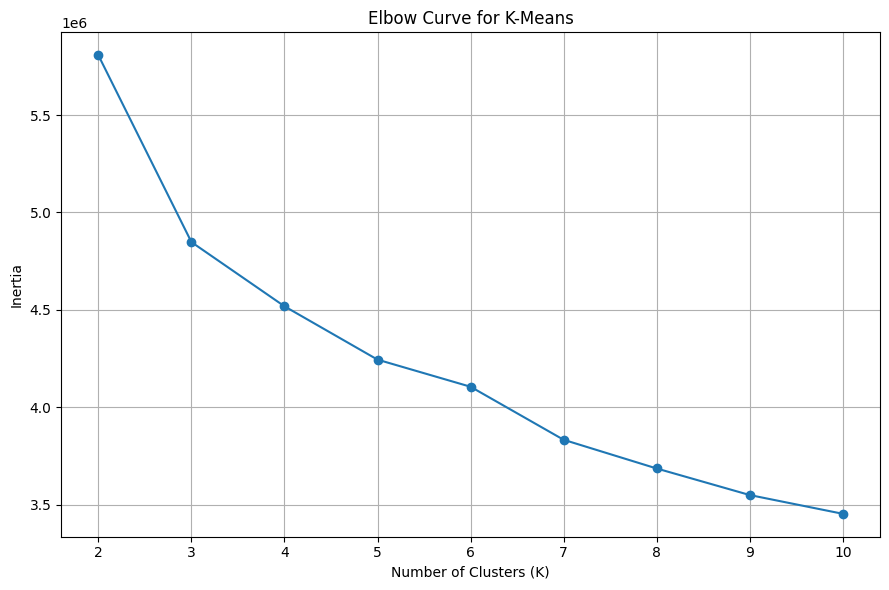

In [35]:
# Plot the Elbow Curve

plt.figure(figsize=(9, 6))

plt.plot(
    elbow_results["K"],
    elbow_results["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve for K-Means")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

### *6.2 Silhouette Analysis for Candidate K Values*

The Silhouette Score measures how similar an observation is to its own cluster compared with other clusters.

The score ranges from -1 to 1:

- Higher values indicate better-defined cluster separation.
- Values near zero indicate overlapping clusters.
- Negative values may indicate observations assigned to an unsuitable cluster.

Silhouette scores are calculated for the candidate K values to complement the Elbow Method.

In [38]:
# Calculate Silhouette Scores using a representative sample
# to reduce computation time.

SILHOUETTE_SAMPLE_SIZE = 10000

# Use a reproducible random sample
sample_size = min(
    SILHOUETTE_SAMPLE_SIZE,
    len(X_scaled)
)

sample_indices = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_silhouette = X_scaled.iloc[sample_indices]

print("Silhouette sample size:", len(X_silhouette))

silhouette_results = []

for k in k_values:
    
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )
    
    labels = kmeans_model.fit_predict(
        X_silhouette
    )
    
    score = silhouette_score(
        X_silhouette,
        labels
    )
    
    silhouette_results.append({
        "K": k,
        "Silhouette Score": score
    })

silhouette_results = pd.DataFrame(
    silhouette_results
)

display(silhouette_results)

Silhouette sample size: 10000


,K,Silhouette Score
0,2,0.188889
1,3,0.205980
2,4,0.171304
3,5,0.171615
4,6,0.137472
5,7,0.131436
6,8,0.129061
7,9,0.126986
8,10,0.119183


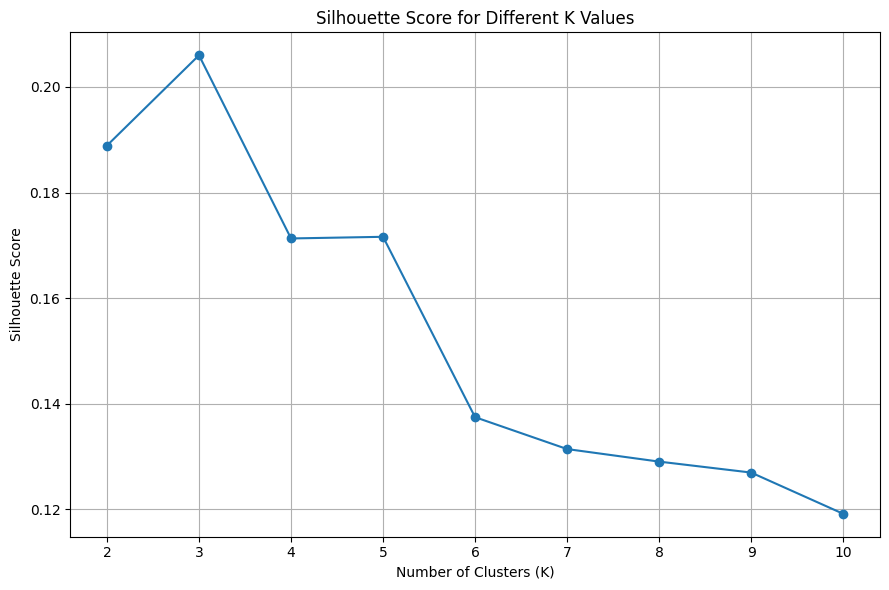

In [39]:
# Plot Silhouette Score by K

plt.figure(figsize=(9, 6))

plt.plot(
    silhouette_results["K"],
    silhouette_results["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(list(k_values))
plt.grid(True)
plt.tight_layout()
plt.show()

### *6.3 Selection of K*

The Elbow Curve and Silhouette analysis were examined together to determine a suitable number of clusters.

The Silhouette analysis produced its highest score at **K = 3**, with a score of approximately **0.206**.

Therefore, **K = 3** is selected for the final K-Means model. This value provides the best Silhouette Score among the tested K values and will be used for the final clustering analysis.

In [41]:
# Fit the final K-Means model using K = 3

FINAL_K = 3

kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(X_scaled)

print("K-Means model fitted successfully.")
print("Number of clusters:", FINAL_K)
print("Number of observations:", len(kmeans_labels))

K-Means model fitted successfully.
Number of clusters: 3
Number of observations: 420768


### *6.4 K-Means Cluster Assignment*

The final K-Means model assigns every observation to one of the three identified clusters.

The resulting cluster labels are added to a separate DataFrame for subsequent evaluation, visualization and cluster profiling.

In [42]:
# Store K-Means cluster assignments

kmeans_results = air_quality_df.copy()

kmeans_results["KMeans_Cluster"] = kmeans_labels

print("Cluster labels added successfully.")

print("\nCluster distribution:")
display(
    kmeans_results["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

Cluster labels added successfully.

Cluster distribution:


KMeans_Cluster
0    139243
1    190158
2     91367
Name: count, dtype: int64

### *6.5 K-Means Cluster Distribution*

The number of observations assigned to each K-Means cluster is examined to determine whether the resulting groups are reasonably represented in the dataset.

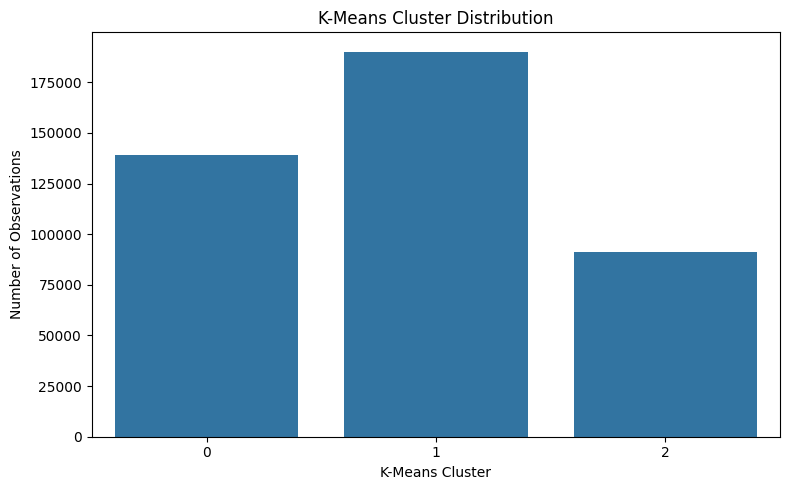

In [44]:
# Visualize K-Means cluster sizes

cluster_counts = (
    kmeans_results["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index.astype(str),
    y=cluster_counts.values
)

plt.xlabel("K-Means Cluster")
plt.ylabel("Number of Observations")
plt.title("K-Means Cluster Distribution")
plt.tight_layout()
plt.show()

### *6.6 K-Means Evaluation*

The final K-Means clustering is evaluated using three mandatory clustering metrics:

- **Silhouette Score** — measures cluster cohesion and separation. Higher values are generally better.
- **Davies-Bouldin Index** — measures similarity between clusters. Lower values indicate better separation.
- **Calinski-Harabasz Index** — compares between-cluster dispersion with within-cluster dispersion. Higher values generally indicate better-defined clusters.

The Silhouette Score is calculated on the same reproducible sample used during K selection because calculating it on all 420,768 observations is computationally expensive.

In [45]:
# Evaluate the final K-Means model

# Silhouette Score using the previously created sample
kmeans_sample_labels = kmeans_labels[sample_indices]

kmeans_silhouette = silhouette_score(
    X_silhouette,
    kmeans_sample_labels
)

# Davies-Bouldin Index on the complete dataset
kmeans_davies_bouldin = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

# Calinski-Harabasz Index on the complete dataset
kmeans_calinski_harabasz = calinski_harabasz_score(
    X_scaled,
    kmeans_labels
)

kmeans_metrics = pd.DataFrame({
    "Algorithm": ["K-Means"],
    "Silhouette Score": [kmeans_silhouette],
    "Davies-Bouldin Index": [kmeans_davies_bouldin],
    "Calinski-Harabasz Index": [kmeans_calinski_harabasz]
})

display(kmeans_metrics)

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.205754,1.602526,100034.545464


## *7. Agglomerative Hierarchical Clustering*

Agglomerative Hierarchical Clustering is an unsupervised clustering method that starts with each observation as an individual cluster and progressively merges the closest clusters.

The process continues until the desired number of clusters is obtained.

A dendrogram is used to visualize the hierarchical merging process.

Because the dataset contains more than 420,000 observations, fitting hierarchical clustering directly on the complete dataset would require excessive computational resources. Therefore, a reproducible sample is used for hierarchical clustering and dendrogram visualization.

The same feature space prepared during preprocessing is used for this algorithm.

### *7.1 Sampling Observations for Hierarchical Clustering*

Hierarchical clustering has substantially higher computational and memory requirements than K-Means for large datasets.

A reproducible sample of 5,000 observations is therefore selected for the hierarchical analysis.

The sampling process uses the project-wide random state of 42 to ensure reproducibility.

In [46]:
# Create a reproducible sample for hierarchical clustering

HIERARCHICAL_SAMPLE_SIZE = 5000

hierarchical_sample_size = min(
    HIERARCHICAL_SAMPLE_SIZE,
    len(X_scaled)
)

hierarchical_indices = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X_scaled),
    size=hierarchical_sample_size,
    replace=False
)

X_hierarchical = X_scaled.iloc[
    hierarchical_indices
].copy()

print(
    "Hierarchical clustering sample size:",
    len(X_hierarchical)
)

Hierarchical clustering sample size: 5000


### *7.2 Dendrogram*

A dendrogram represents the hierarchy of cluster merges produced by hierarchical clustering.

The vertical axis represents the linkage distance at which clusters are merged.

The Ward linkage method is used because it attempts to minimize the increase in within-cluster variance when clusters are merged.

In [47]:
# Generate the linkage matrix for the dendrogram

hierarchical_linkage = linkage(
    X_hierarchical,
    method="ward"
)

print("Linkage matrix created successfully.")
print("Linkage matrix shape:", hierarchical_linkage.shape)

Linkage matrix created successfully.
Linkage matrix shape: (4999, 4)


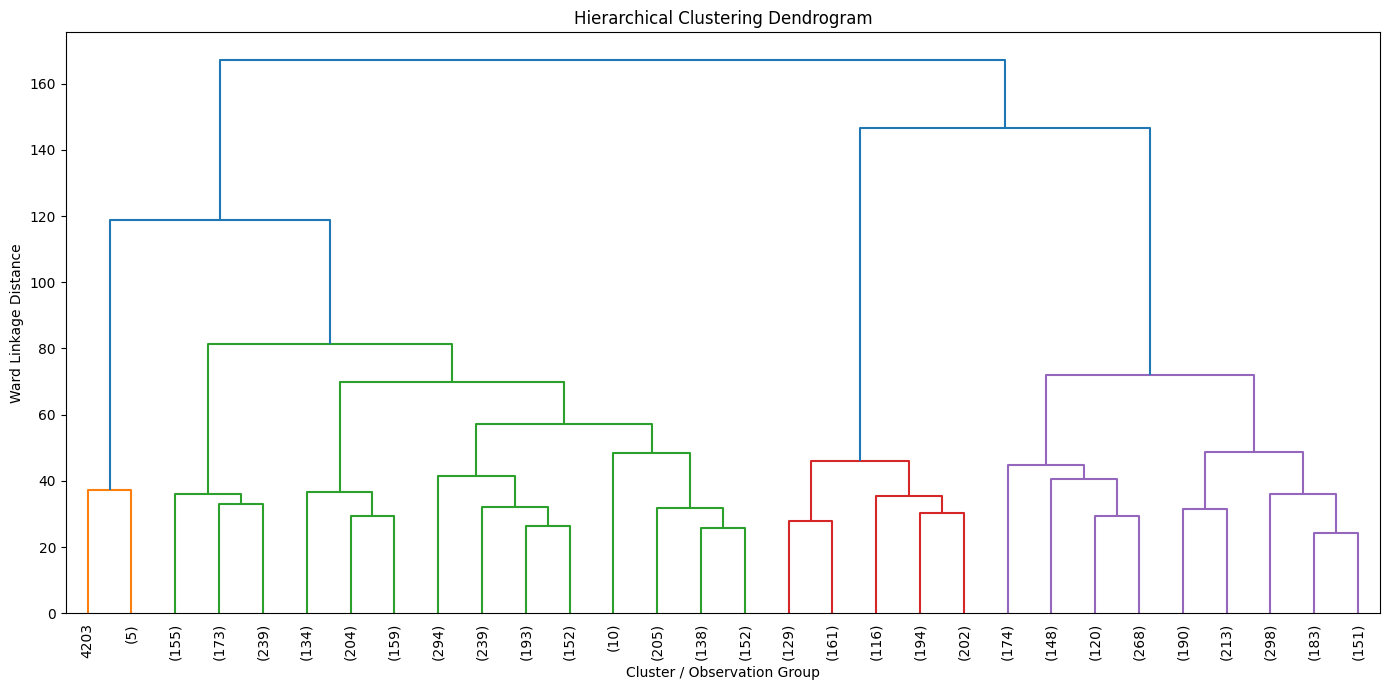

In [48]:
# Plot the dendrogram

plt.figure(figsize=(14, 7))

dendrogram(
    hierarchical_linkage,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.xlabel("Cluster / Observation Group")
plt.ylabel("Ward Linkage Distance")
plt.title("Hierarchical Clustering Dendrogram")
plt.tight_layout()
plt.show()

### *7.3 Final Agglomerative Clustering Model*

The K-Means analysis identified three clusters based on the Elbow and Silhouette analyses.

To provide a comparable clustering solution, Agglomerative Hierarchical Clustering is also fitted using three clusters.

Ward linkage is used for the final model.

In [49]:
# Fit the final Agglomerative Hierarchical Clustering model

hierarchical_final = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical_final.fit_predict(
    X_hierarchical
)

print("Agglomerative Hierarchical Clustering completed.")
print("Number of clusters:", len(
    np.unique(hierarchical_labels)
))

Agglomerative Hierarchical Clustering completed.
Number of clusters: 3


### *7.4 Hierarchical Cluster Distribution*

The number of observations assigned to each hierarchical cluster is examined to determine how the sampled observations are distributed among the three clusters.

In [50]:
# Examine hierarchical cluster sizes

hierarchical_cluster_counts = pd.Series(
    hierarchical_labels
).value_counts().sort_index()

display(
    hierarchical_cluster_counts.to_frame(
        name="Number of Observations"
    )
)

,Number of Observations
0,2453
1,1745
2,802


### *7.5 Agglomerative Clustering Evaluation*

The hierarchical clustering solution is evaluated using the same three clustering metrics used for K-Means:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

The metrics are calculated on the hierarchical-clustering sample because the full dataset is computationally unsuitable for Agglomerative Clustering.

In [51]:
# Evaluate Agglomerative Hierarchical Clustering

hierarchical_silhouette = silhouette_score(
    X_hierarchical,
    hierarchical_labels
)

hierarchical_davies_bouldin = davies_bouldin_score(
    X_hierarchical,
    hierarchical_labels
)

hierarchical_calinski_harabasz = calinski_harabasz_score(
    X_hierarchical,
    hierarchical_labels
)

hierarchical_metrics = pd.DataFrame({
    "Algorithm": [
        "Agglomerative Hierarchical"
    ],
    "Silhouette Score": [
        hierarchical_silhouette
    ],
    "Davies-Bouldin Index": [
        hierarchical_davies_bouldin
    ],
    "Calinski-Harabasz Index": [
        hierarchical_calinski_harabasz
    ]
})

display(hierarchical_metrics)

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,Agglomerative Hierarchical,0.177969,1.71298,947.090031


## *8. Dimensionality Reduction and Cluster Visualization*

The clustering feature matrix contains multiple environmental, temporal and wind-direction features.

Principal Component Analysis (PCA) is used to project the high-dimensional feature space into two dimensions for visualization.

PCA does not change the clustering assignments. It provides a two-dimensional representation that allows the spatial distribution of the identified clusters to be visually examined.

### *8.1 PCA Visualization of K-Means Clusters*

A reproducible sample of the K-Means results is projected into two principal components.

The K-Means cluster labels obtained from the final model are retained during the projection so that the distribution of the three clusters can be visualized.

In [52]:
# Select a reproducible sample for K-Means PCA visualization

PCA_SAMPLE_SIZE = 5000

pca_sample_size = min(
    PCA_SAMPLE_SIZE,
    len(X_scaled)
)

pca_indices = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X_scaled),
    size=pca_sample_size,
    replace=False
)

X_kmeans_pca_sample = X_scaled.iloc[
    pca_indices
]

kmeans_pca_labels = kmeans_labels[
    pca_indices
]

print(
    "K-Means PCA sample size:",
    len(X_kmeans_pca_sample)
)

K-Means PCA sample size: 5000


In [53]:
# Apply PCA to the K-Means sample

pca_kmeans = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_kmeans_pca = pca_kmeans.fit_transform(
    X_kmeans_pca_sample
)

print(
    "Explained variance by PC1:",
    round(pca_kmeans.explained_variance_ratio_[0], 4)
)

print(
    "Explained variance by PC2:",
    round(pca_kmeans.explained_variance_ratio_[1], 4)
)

print(
    "Total explained variance:",
    round(
        pca_kmeans.explained_variance_ratio_.sum(),
        4
    )
)

Explained variance by PC1: 0.2522
Explained variance by PC2: 0.2024
Total explained variance: 0.4546


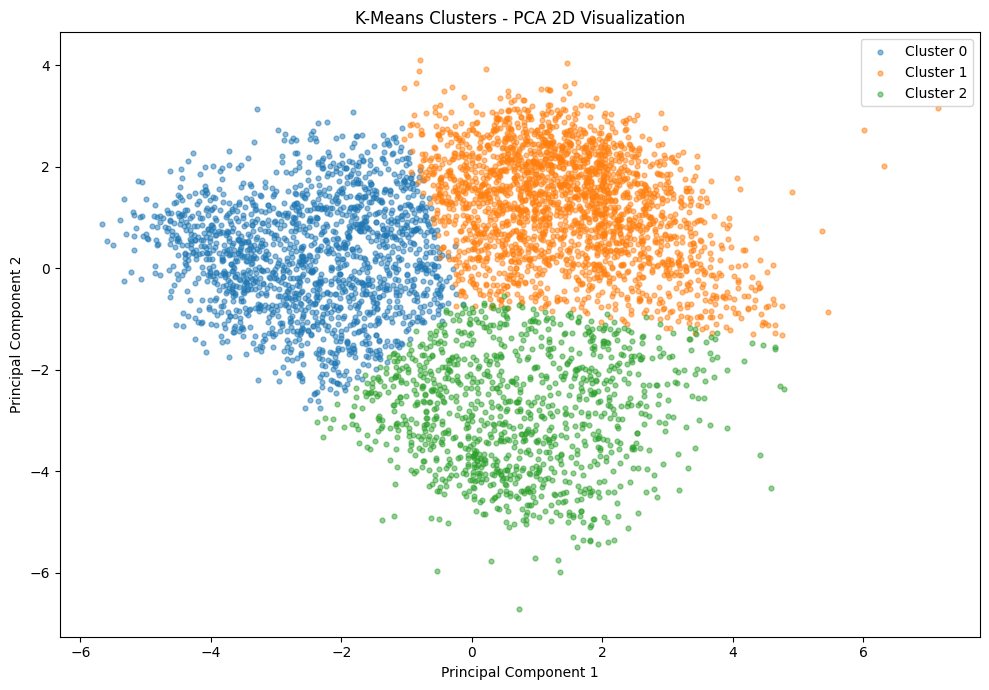

In [54]:
# Plot K-Means clusters in PCA space

plt.figure(figsize=(10, 7))

for cluster in sorted(np.unique(kmeans_pca_labels)):
    
    mask = kmeans_pca_labels == cluster
    
    plt.scatter(
        X_kmeans_pca[mask, 0],
        X_kmeans_pca[mask, 1],
        s=12,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters - PCA 2D Visualization")
plt.legend()
plt.tight_layout()
plt.show()

### *8.2 PCA Visualization of Agglomerative Clusters*

The 5,000 observations used for Agglomerative Hierarchical Clustering are projected into two principal components.

The resulting two-dimensional representation is used to visualize the spatial distribution of the hierarchical clusters.

In [55]:
# Apply PCA to the hierarchical clustering sample

pca_hierarchical = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_hierarchical_pca = pca_hierarchical.fit_transform(
    X_hierarchical
)

print(
    "Explained variance by PC1:",
    round(
        pca_hierarchical.explained_variance_ratio_[0],
        4
    )
)

print(
    "Explained variance by PC2:",
    round(
        pca_hierarchical.explained_variance_ratio_[1],
        4
    )
)

print(
    "Total explained variance:",
    round(
        pca_hierarchical.explained_variance_ratio_.sum(),
        4
    )
)

Explained variance by PC1: 0.2522
Explained variance by PC2: 0.2024
Total explained variance: 0.4546


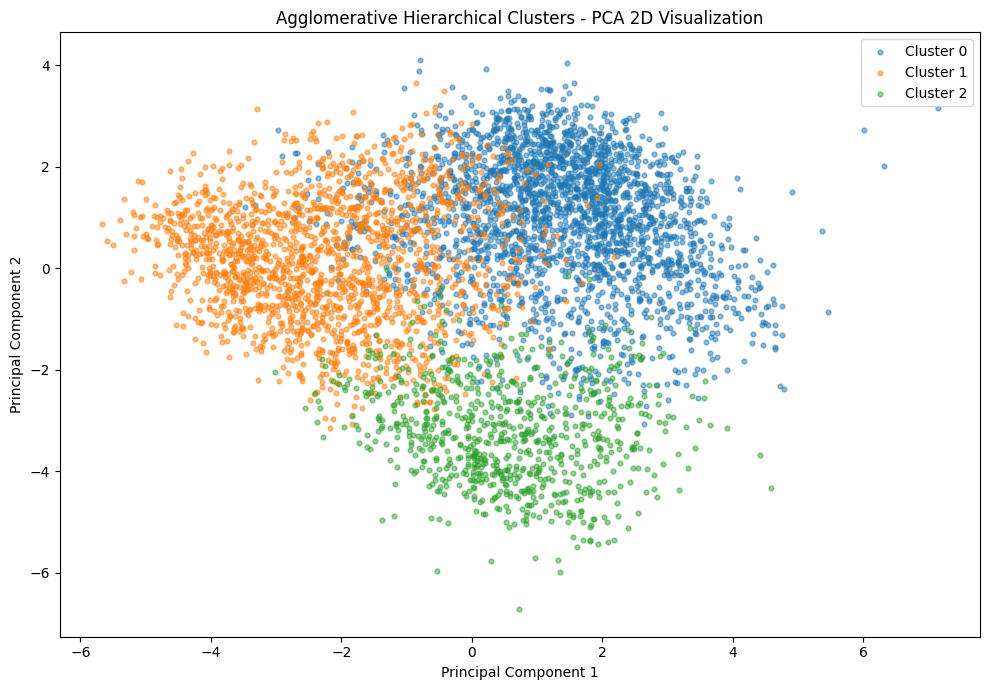

In [56]:
# Plot hierarchical clusters in PCA space

plt.figure(figsize=(10, 7))

for cluster in sorted(
    np.unique(hierarchical_labels)
):
    
    mask = hierarchical_labels == cluster
    
    plt.scatter(
        X_hierarchical_pca[mask, 0],
        X_hierarchical_pca[mask, 1],
        s=12,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(
    "Agglomerative Hierarchical Clusters - PCA 2D Visualization"
)
plt.legend()
plt.tight_layout()
plt.show()

## *9. t-SNE Visualization*

t-SNE (t-distributed Stochastic Neighbor Embedding) is a nonlinear dimensionality-reduction technique that emphasizes local similarities between observations.

It is used here to provide an additional two-dimensional visualization of the K-Means clusters.

Because t-SNE is computationally expensive for very large datasets, a reproducible sample of observations is used. PCA is first applied to reduce the feature space before t-SNE.

In [57]:
# Create a reproducible sample for t-SNE

TSNE_SAMPLE_SIZE = 2000

tsne_sample_size = min(
    TSNE_SAMPLE_SIZE,
    len(X_scaled)
)

tsne_indices = np.random.RandomState(
    RANDOM_STATE
).choice(
    len(X_scaled),
    size=tsne_sample_size,
    replace=False
)

X_tsne_sample = X_scaled.iloc[
    tsne_indices
]

tsne_labels = kmeans_labels[
    tsne_indices
]

print(
    "t-SNE sample size:",
    len(X_tsne_sample)
)

t-SNE sample size: 2000


In [58]:
# Reduce the t-SNE input to 10 PCA components

pca_tsne = PCA(
    n_components=10,
    random_state=RANDOM_STATE
)

X_tsne_pca = pca_tsne.fit_transform(
    X_tsne_sample
)

print(
    "t-SNE input shape:",
    X_tsne_pca.shape
)

t-SNE input shape: (2000, 10)


In [59]:
# Apply t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE
)

X_tsne = tsne.fit_transform(
    X_tsne_pca
)

print("t-SNE completed successfully.")
print("t-SNE output shape:", X_tsne.shape)

t-SNE completed successfully.
t-SNE output shape: (2000, 2)


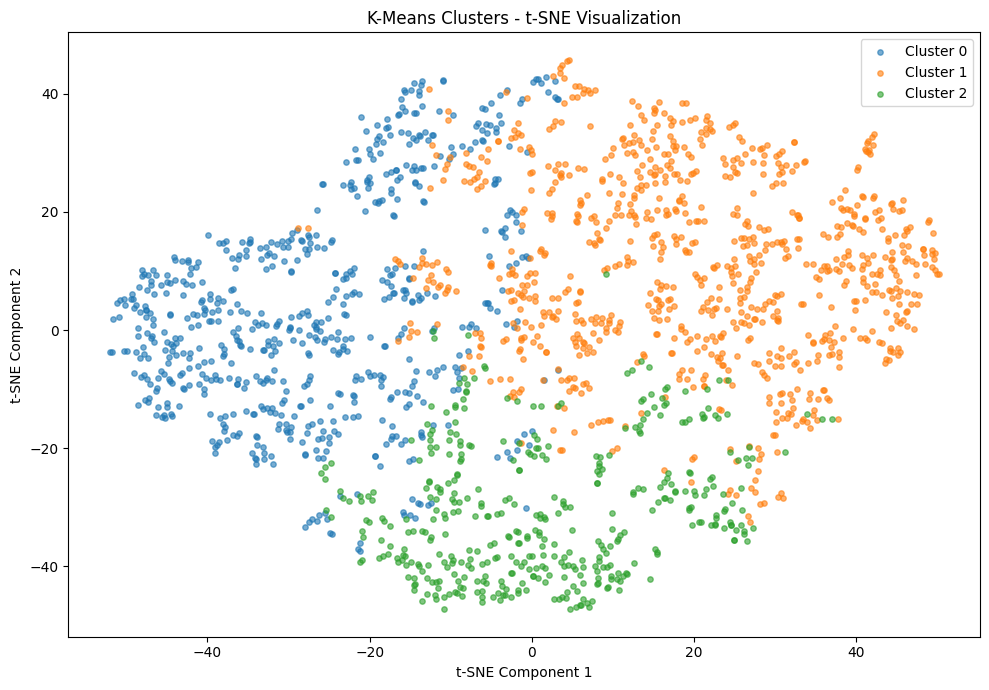

In [60]:
# Plot K-Means clusters using t-SNE

plt.figure(figsize=(10, 7))

for cluster in sorted(
    np.unique(tsne_labels)
):
    
    mask = tsne_labels == cluster
    
    plt.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        s=15,
        alpha=0.6,
        label=f"Cluster {cluster}"
    )

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("K-Means Clusters - t-SNE Visualization")
plt.legend()
plt.tight_layout()
plt.show()

## *10. Cluster Profiling*

After obtaining the cluster assignments, the characteristics of the identified clusters are examined using the original air-quality and meteorological measurements.

Cluster profiles are created using mean pollutant concentrations and meteorological variables.

The original feature values are used for interpretation so that the resulting profiles remain expressed in meaningful physical units.

Cluster numbers are arbitrary labels and do not inherently indicate an air-quality severity ranking.

### *10.1 K-Means Cluster Profiles*

The average environmental characteristics of each K-Means cluster are calculated.

The profile includes pollutant concentrations and meteorological variables used during the clustering analysis.

In [61]:
# Define variables for cluster profiling

profile_features = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]

# Calculate mean values for each K-Means cluster

kmeans_cluster_profiles = (
    kmeans_results
    .groupby("KMeans_Cluster")[profile_features]
    .mean()
)

display(kmeans_cluster_profiles)

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
KMeans_Cluster,,,,,,,,,,,
0,138.801297,167.249596,31.571294,83.437430,2223.709223,16.758728,4.647715,1016.951451,-3.686284,0.013600,1.193484
1,67.333744,91.479973,8.364335,40.022911,888.581068,87.208131,23.579155,1002.259873,14.281056,0.128254,1.588847
2,15.615857,36.459724,7.247795,22.554180,425.453101,56.855518,6.176655,1018.969975,-12.657258,0.009159,2.840640


In [62]:
# Combine cluster sizes with their environmental profiles

kmeans_profile_summary = kmeans_cluster_profiles.copy()

kmeans_profile_summary.insert(
    0,
    "Cluster Size",
    kmeans_results["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)

display(kmeans_profile_summary)

,Cluster Size,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
KMeans_Cluster,,,,,,,,,,,,
0,139243,138.801297,167.249596,31.571294,83.437430,2223.709223,16.758728,4.647715,1016.951451,-3.686284,0.013600,1.193484
1,190158,67.333744,91.479973,8.364335,40.022911,888.581068,87.208131,23.579155,1002.259873,14.281056,0.128254,1.588847
2,91367,15.615857,36.459724,7.247795,22.554180,425.453101,56.855518,6.176655,1018.969975,-12.657258,0.009159,2.840640


### *10.2 Station Distribution Across K-Means Clusters*

The distribution of monitoring stations within each K-Means cluster is examined to determine whether particular clusters are associated with specific monitoring locations.

The station identifier is used only for post-clustering interpretation and was not used as a clustering feature.

In [63]:
# Examine station distribution within each K-Means cluster

station_cluster_distribution = pd.crosstab(
    kmeans_results["KMeans_Cluster"],
    kmeans_results["station"]
)

display(station_cluster_distribution)

station,Aotizhongxin,Changping,Dingling,Dongsi,Guanyuan,Gucheng,Huairou,Nongzhanguan,Shunyi,Tiantan,Wanliu,Wanshouxigong
KMeans_Cluster,,,,,,,,,,,,
0,12520,10237,8168,12262,12325,12525,9568,12491,11314,12128,13358,12347
1,15389,16703,16533,15348,15707,16219,16853,15223,15489,15673,15381,15640
2,7155,8124,10363,7454,7032,6320,8643,7350,8261,7263,6325,7077


In [64]:
# Calculate percentage distribution of stations within each cluster

station_cluster_percentage = (
    pd.crosstab(
        kmeans_results["KMeans_Cluster"],
        kmeans_results["station"],
        normalize="index"
    ) * 100
)

display(
    station_cluster_percentage.round(2)
)

station,Aotizhongxin,Changping,Dingling,Dongsi,Guanyuan,Gucheng,Huairou,Nongzhanguan,Shunyi,Tiantan,Wanliu,Wanshouxigong
KMeans_Cluster,,,,,,,,,,,,
0,8.99,7.35,5.87,8.81,8.85,9.00,6.87,8.97,8.13,8.71,9.59,8.87
1,8.09,8.78,8.69,8.07,8.26,8.53,8.86,8.01,8.15,8.24,8.09,8.22
2,7.83,8.89,11.34,8.16,7.70,6.92,9.46,8.04,9.04,7.95,6.92,7.75


### *10.3 Visualization of K-Means Cluster Profiles*

A heatmap is used to visualize differences in the average environmental characteristics of the three K-Means clusters.

Because the variables have different units, the cluster-profile values are standardized for visualization only.

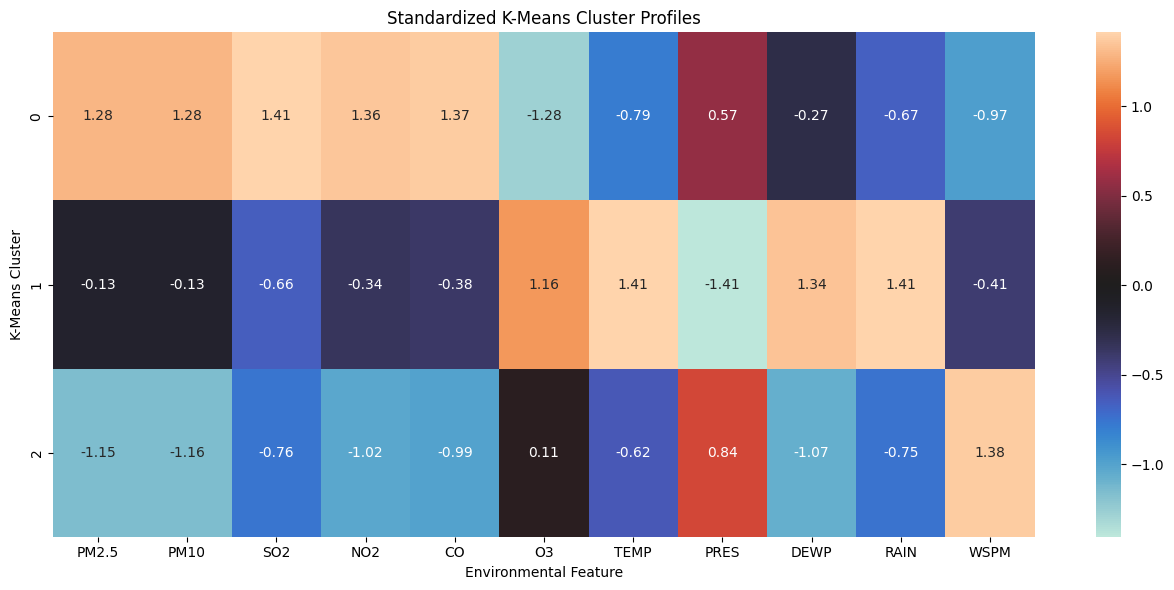

In [65]:
# Standardize cluster profiles for visualization

profile_scaler = StandardScaler()

profile_scaled = profile_scaler.fit_transform(
    kmeans_cluster_profiles
)

profile_scaled_df = pd.DataFrame(
    profile_scaled,
    index=kmeans_cluster_profiles.index,
    columns=kmeans_cluster_profiles.columns
)

plt.figure(figsize=(13, 6))

sns.heatmap(
    profile_scaled_df,
    annot=True,
    fmt=".2f",
    center=0
)

plt.xlabel("Environmental Feature")
plt.ylabel("K-Means Cluster")
plt.title("Standardized K-Means Cluster Profiles")
plt.tight_layout()
plt.show()

## *11. Clustering Model Comparison*

The K-Means and Agglomerative Hierarchical Clustering models are compared using the three required evaluation metrics.

The comparison table provides a consolidated summary of the clustering results.

The evaluation sample sizes are also reported because K-Means metrics were evaluated using the complete dataset for Davies-Bouldin and Calinski-Harabasz, while the hierarchical model was evaluated using a 5,000-observation sample.

In [66]:
# Combine evaluation metrics

comparison_results = pd.concat(
    [
        kmeans_metrics,
        hierarchical_metrics
    ],
    ignore_index=True
)

comparison_results["Evaluation Sample Size"] = [
    len(X_scaled),
    len(X_hierarchical)
]

display(comparison_results)

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Evaluation Sample Size
0,K-Means,0.205754,1.602526,100034.545464,420768
1,Agglomerative Hierarchical,0.177969,1.712980,947.090031,5000


In [69]:
# Save clustering comparison results

# Create the clustering results directory

results_dir = Path("../results/clustering")

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

# Save clustering comparison results

comparison_results.to_csv(
    results_dir / "clustering_comparison.csv",
    index=False
)

print("Clustering comparison saved successfully.")
print("Location:", results_dir / "clustering_comparison.csv")

Clustering comparison saved successfully.
Location: ..\results\clustering\clustering_comparison.csv


## *12. Final Clustering Results*

Two unsupervised clustering algorithms were implemented:

1. K-Means Clustering
2. Agglomerative Hierarchical Clustering

K-Means was configured with three clusters based on the Elbow analysis and Silhouette analysis. The highest Silhouette Score among the tested K values was obtained at K = 3.

Agglomerative Hierarchical Clustering was also configured with three clusters using Ward linkage.

The models were evaluated using:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

PCA and t-SNE were used to visualize the resulting cluster structures.

The cluster profiles were then examined using the original environmental measurements to understand the characteristics of the identified groups.

### *12.1 Cluster Interpretation*

The K-Means clustering produced three environmental profiles.

**Cluster 0** contains 139,243 observations and is characterized by the highest average concentrations of PM2.5, PM10, SO2, NO2 and CO among the three clusters. It also has comparatively lower O3, temperature and wind speed.

**Cluster 1** contains 190,158 observations and shows intermediate concentrations of PM2.5, PM10, SO2, NO2 and CO. It has the highest average O3 concentration and temperature among the three clusters.

**Cluster 2** contains 91,367 observations and has the lowest average concentrations of PM2.5, PM10, SO2, NO2 and CO. It also has the highest average wind speed among the three clusters.

The station distribution indicates that the identified clusters occur across multiple monitoring locations rather than corresponding directly to individual stations.

These cluster labels are descriptive identifiers and do not represent an inherent ranking of air-quality conditions.

## *13. Conclusion*

This clustering analysis applied unsupervised machine learning techniques to the Beijing Multi-Site Air Quality dataset containing observations from 12 monitoring stations.

The preprocessing stage addressed missing values, temporal representation, cyclic wind direction, skewed pollutant distributions and feature scaling.

Two clustering algorithms were implemented:

1. K-Means Clustering
2. Agglomerative Hierarchical Clustering

For K-Means, the Elbow Method and Silhouette analysis were used to select three clusters. The final K-Means model was evaluated using Silhouette Score, Davies-Bouldin Index and Calinski-Harabasz Index.

Agglomerative Hierarchical Clustering was implemented using Ward linkage with three clusters. A dendrogram was generated to visualize the hierarchical structure.

PCA visualizations were produced for both clustering algorithms, while t-SNE was used to provide an additional visualization of the K-Means cluster structure.

The resulting K-Means cluster profiles showed differences in pollutant concentrations and meteorological conditions, demonstrating that the dataset contains distinguishable environmental patterns.

Overall, the clustering analysis provides an unsupervised characterization of air-quality observations based on their pollutant and environmental measurements.

## *14. Clustering Results Summary*

| Algorithm | Number of Clusters | Silhouette Score | Davies-Bouldin Index | Calinski-Harabasz Index |
|---|---:|---:|---:|---:|
| K-Means | 3 | 0.205754 | 1.602526 | 100034.545464 |
| Agglomerative Hierarchical | 3 | 0.177969 | 1.712980 | 947.090031 |

The metrics provide quantitative measures of the clustering structure. The evaluation datasets differ in size because K-Means was fitted to the complete dataset, while hierarchical clustering was performed on a 5,000-observation sample due to its substantially higher computational requirements.